# Netflix Data Analysis

## Project Overview

This project performs Exploratory Data Analysis (EDA) on the Netflix Titles dataset. The objective is to clean the dataset, explore trends in Netflix's catalog, and uncover insights about content types, ratings, countries, genres, directors, actors, and release patterns.

## Objectives

- Perform data cleaning
- Handle missing values
- Create meaningful visualizations
- Extract business insights

## Dataset

The dataset contains information about movies and TV shows available on Netflix.

It includes:

- Show ID
- Title
- Type
- Director
- Cast
- Country
- Date Added
- Release Year
- Rating
- Duration
- Genre
- Description

## 1. Data Loading

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv('../data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [49]:
df.shape

(8807, 12)

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [51]:
df.describe(include = 'all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [52]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [53]:
(df.isnull().sum() / len(df)) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [54]:
duplicates = df[df.duplicated()]
print(f"Found {len(duplicates)} duplicate rows.")

Found 0 duplicate rows.


In [55]:
print(df.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [56]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [57]:
print(df["type"].unique())
print(df["rating"].unique())
print(df["country"].unique())
print(df["listed_in"].unique())

<ArrowStringArray>
['Movie', 'TV Show']
Length: 2, dtype: str
<ArrowStringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR',        nan, 'TV-Y7-FV',       'UR']
Length: 18, dtype: str
<ArrowStringArray>
[                                                        'United States',
                                                          'South Africa',
                                                                     nan,
                                                                 'India',
 'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
                                                        'United Kingdom',
                                               'Germany, Czech Republic',
                                                                'Mexico',
                                                                'T

In [58]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

## 2. Data Cleaning

In [59]:
df_clean = df.copy()

In [60]:
df_clean.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### Handling Missing Values

- Director, Cast, and Country were filled with "Unknown" because removing these rows would result in a significant loss of data.
- Date Added, Rating, and Duration contained only a few missing values, so those rows were removed.

In [61]:
df_clean["director"] = df_clean["director"].fillna("Unknown")

In [62]:
df_clean["cast"] = df_clean["cast"].fillna("Unknown")

In [63]:
df_clean["country"] = df_clean["country"].fillna("Unknown")

In [64]:
df_clean = df_clean.dropna(subset=["date_added"])

In [65]:
df_clean = df_clean.dropna(subset=["rating"])

In [66]:
df_clean = df_clean.dropna(subset=["duration"])

In [67]:
# There are now no missing values in the dataset
df_clean.isnull().sum()


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [68]:
df_clean["date_added"].dtype


<StringDtype(na_value=nan)>

In [69]:
# Strip whitespace from the column strings
df_clean["date_added"] = df_clean["date_added"].str.strip()
df_clean["date_added"] = pd.to_datetime(df_clean["date_added"])

In [70]:
df_clean["date_added"].dtype


dtype('<M8[us]')

In [71]:
df_clean["year_added"] = df_clean["date_added"].dt.year
df_clean["month_added"] = df_clean["date_added"].dt.month_name()
df_clean["day_added"] = df_clean["date_added"].dt.day

In [72]:
df_clean[["date_added", "year_added", "month_added", "day_added"]].head()

,date_added,year_added,month_added,day_added
0,2021-09-25,2021,September,25
1,2021-09-24,2021,September,24
2,2021-09-24,2021,September,24
3,2021-09-24,2021,September,24
4,2021-09-24,2021,September,24


In [73]:
df_clean["duration_value"] = (
    df_clean["duration"]
    .str.extract(r"(\d+)")
    .astype(int)
)
df_clean["duration_unit"] = (
    df_clean["duration"]
    .str.extract(r"([A-Za-z]+)")
)


In [74]:
df_clean[["duration", "duration_value", "duration_unit"]].head(10)

,duration,duration_value,duration_unit
0,90 min,90,min
1,2 Seasons,2,Seasons
2,1 Season,1,Season
3,1 Season,1,Season
4,2 Seasons,2,Seasons
5,1 Season,1,Season
6,91 min,91,min
7,125 min,125,min
8,9 Seasons,9,Seasons
9,104 min,104,min


In [75]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         8790 non-null   str           
 1   type            8790 non-null   str           
 2   title           8790 non-null   str           
 3   director        8790 non-null   str           
 4   cast            8790 non-null   str           
 5   country         8790 non-null   str           
 6   date_added      8790 non-null   datetime64[us]
 7   release_year    8790 non-null   int64         
 8   rating          8790 non-null   str           
 9   duration        8790 non-null   str           
 10  listed_in       8790 non-null   str           
 11  description     8790 non-null   str           
 12  year_added      8790 non-null   int32         
 13  month_added     8790 non-null   str           
 14  day_added       8790 non-null   int32         
 15  duration_value  8790

In [ ]:
df_clean.to_csv("./data/netflix_titles_cleaned.csv", index=False)

## 3. Exploratory Data Analysis (EDA)

Each visualization below explores a specific business question and summarizes the key findings.

In [77]:
# What is the distribution of Movies vs TV Shows on Netflix?
print(df_clean["type"].value_counts())
print((df_clean["type"].value_counts(normalize=True) * 100).round(2))

type
Movie      6126
TV Show    2664
Name: count, dtype: int64
type
Movie      69.69
TV Show    30.31
Name: proportion, dtype: float64


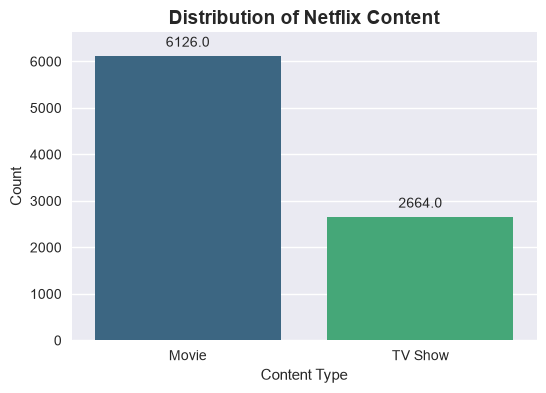

In [ ]:
plt.style.use("seaborn-v0_8")
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df_clean, x="type", hue="type", palette="viridis", legend=False)

# Calculate the maximum count to set the y-limit dynamically
max_count = df_clean["type"].value_counts().max()
plt.ylim(0, max_count + 500) # Adds 500 units of extra space at the top

# Add the count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.title("Distribution of Netflix Content", fontsize = 14, fontweight='bold')
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.savefig("./images/content_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Observation

Movies make up a significantly larger portion of Netflix's catalog than TV Shows. This indicates that Netflix places a stronger emphasis on offering movie content, providing users with a wider selection of films than television series.

### Insights
Netflix appears to prioritize movies over TV shows, suggesting a stronger focus on film content acquisition and production.

In [80]:
# What are the most common content ratings?
df_clean["rating"].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [81]:
rating_counts = df_clean["rating"].value_counts().head(10)

rating_counts


rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

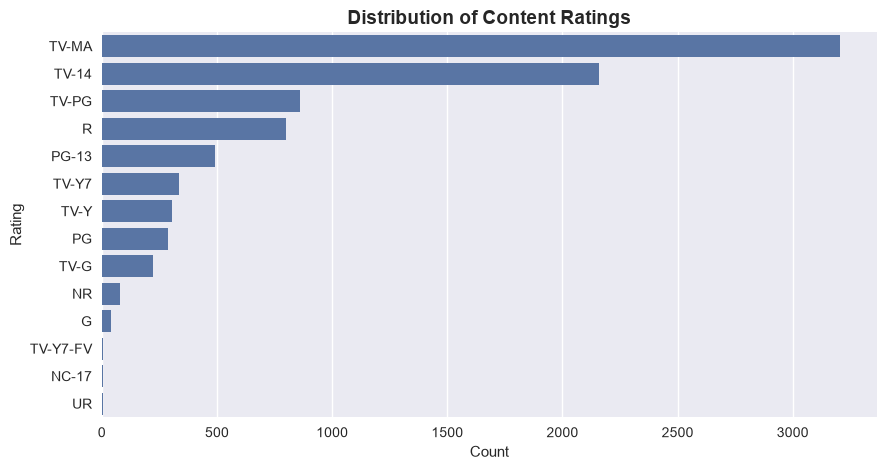

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    y="rating",
    order=df_clean["rating"].value_counts().index
)

plt.title("Distribution of Content Ratings",fontsize = 14,fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Rating")

plt.savefig("./images/content_ratings.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Observation
The content distribution shows that movies dominate Netflix's library, while TV Shows represent a smaller share. This reflects Netflix's broader investment in movie acquisitions and productions.

### Insights
Dominance of Mature Content: The most frequent ratings are TV-MA and TV-14, indicating that a significant majority of the platform's content is geared toward adult and teen audiences.

Skewed Distribution: There is a clear skew toward higher age-appropriateness ratings; the top four categories (TV-MA, TV-14, TV-PG, R) have counts significantly higher than those of family-oriented ratings.

Low Representation of Children's Ratings: Categories typically designated for children, such as TV-Y, TV-Y7, G, and TV-G, account for a relatively small fraction of the total content library.

Minimal Niche/Unrated Content: Ratings such as NC-17 and UR (Unrated) are nearly non-existent in this dataset, suggesting these categories represent a negligible portion of the available titles.

In [84]:
# How has content production changed over the last 25 years?
release_counts = (
    df_clean["release_year"]
    .value_counts()
    .sort_index()
)

release_counts.tail()

release_year
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64

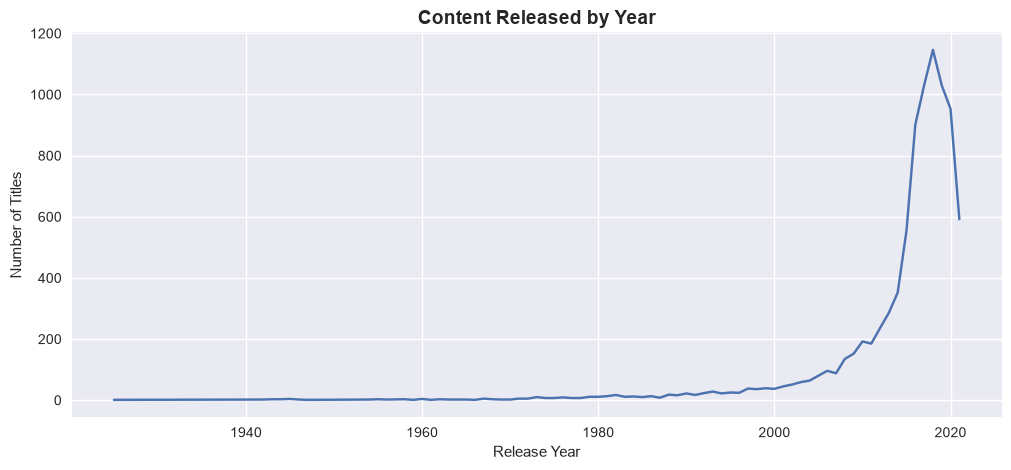

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    release_counts.index,
    release_counts.values
)

plt.title("Content Released by Year",fontsize = 14, fontweight='bold')
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")


plt.savefig("./images/content_release_trend.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Observation
TV-MA is the most common content rating in the dataset, suggesting that Netflix primarily targets mature audiences. Family-friendly ratings such as PG and G appear less frequently in comparison.

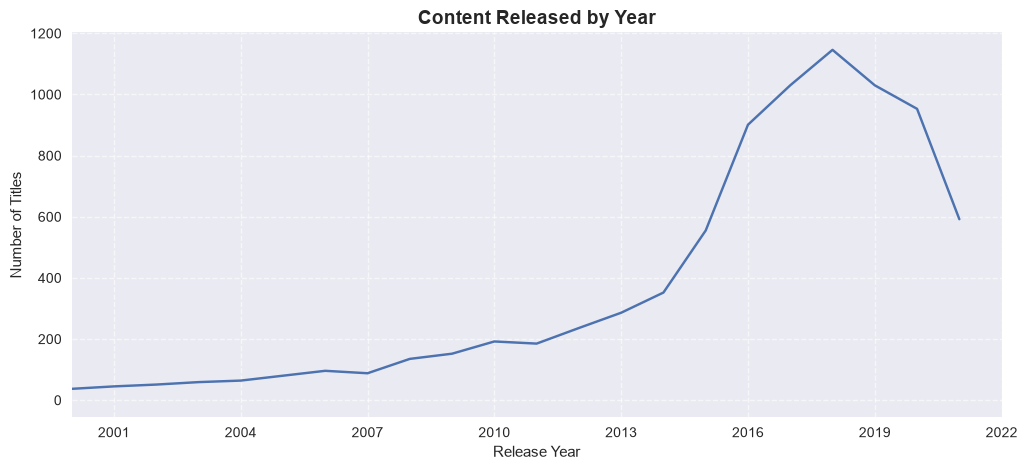

In [ ]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(12, 5))

plt.plot(release_counts.index, release_counts.values)

# Set the x-axis to only show integers
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# Add grid and limit range to focus on the growth trend
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(2000, 2022) 

plt.title("Content Released by Year", fontsize=14, fontweight='bold')
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")


plt.savefig("./images/content_release_trend_last_25_years.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Observation
The number of titles released increased steadily over time, with significant growth after the early 2000s. This trend reflects the expansion of the global entertainment industry and the increasing production of streaming content.

### Insights
Rapid Scaling: The exponential growth between 2015 and 2018 suggests a strategic shift by Netflix toward producing massive amounts of "Original" content during those years.

Data Integrity Warning: The sudden drop-off after 2018 is a classic sign of "right-censoring" in data. When analyzing this, you should explicitly note that the dataset appears to be outdated, meaning any conclusions about Netflix’s current production strategy should not be based on the 2019–2021 period.

Shift in Library Growth: The contrast between the slow, flat growth before 2010 and the massive spikes later suggests the dataset captures the exact moment Netflix transitioned from a streaming service for third-party licensed content into a global production powerhouse.

In [88]:
# How has Netflix's content library grown over time?
year_added_counts = (df_clean["year_added"].value_counts().sort_index())

year_added_counts

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

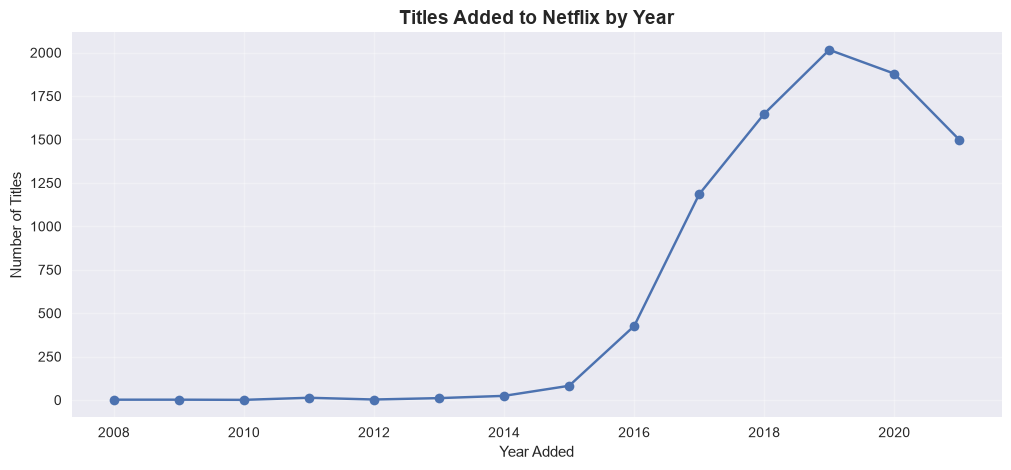

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    year_added_counts.index,
    year_added_counts.values,
    marker='o'
)

plt.title("Titles Added to Netflix by Year", fontsize = 14, fontweight = 'bold')
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.grid(alpha=0.3)


plt.savefig("./images/year_added_trend.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Observation
Focusing on the last 25 years highlights the rapid growth in content production, particularly during the 2010s. The slight decline in the most recent years is likely due to the dataset containing incomplete data for the latest year.

### Insights
The "Originals" Explosion: The dramatic spike starting in 2016 perfectly aligns with the period when Netflix shifted its business model toward heavily investing in and producing its own "Netflix Original" content, rather than relying solely on licensed third-party titles.

Data Stagnation vs. Reality: The drop-off in 2021 should not be interpreted as a decrease in Netflix’s production activity. In data science, this is known as right-censoring, where the observation window closes before the event (content release) is fully captured.

Platform Maturity: The flat period between 2008 and 2015 highlights the time when Netflix was still primarily a DVD-by-mail service or a modest streaming library. The 2016 "hockey stick" growth curve marks the transformation of Netflix into the global streaming giant we recognize today.

In [90]:
# Which countries produce the most Netflix content?
country_counts = (df_clean["country"].str.split(", ").explode().value_counts())

country_counts.head(10)

country
United States     3680
India             1046
Unknown            829
United Kingdom     803
Canada             445
France             393
Japan              316
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

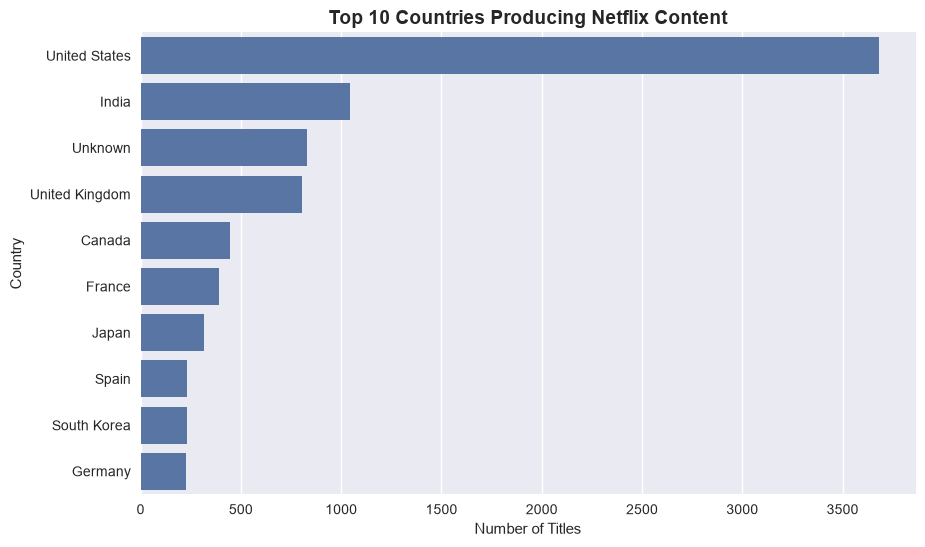

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=country_counts.head(10).values,
    y=country_counts.head(10).index
)

plt.title("Top 10 Countries Producing Netflix Content",fontsize = 14, fontweight = 'bold')
plt.xlabel("Number of Titles")
plt.ylabel("Country")


plt.savefig("./images/country_production.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Observation
The United States is the leading producer of Netflix content, followed by India and several other countries. This demonstrates Netflix's strong presence in major global entertainment markets while maintaining a diverse international catalog.

### Insights
US-Centric Catalog: The massive lead of the U.S. confirms that, historically, Netflix's content library has been heavily weighted toward North American media production.

The "Unknown" Data Gap: Having "Unknown" as a top-three category suggests that a significant portion of the dataset lacks geographical metadata. Before performing any deep-dive geographical analysis, you might want to investigate these "Unknown" rows to see if they can be categorized or if they should be excluded.

Global Expansion: The inclusion of countries like India, South Korea, Japan, and Spain demonstrates Netflix’s aggressive expansion into international markets, moving beyond just U.S.-based content to appeal to diverse global audiences.

Geographical Imbalance: The sharp drop-off in production volume after the top two countries (U.S. and India) shows that content production is highly concentrated in a few major hubs rather than being evenly distributed across the globe.

In [92]:
# What are the most popular genres?
genre_counts = (df_clean["listed_in"].str.split(", ").explode().value_counts())
genre_counts

listed_in
International Movies            2752
Dramas                          2426
Comedies                        1674
International TV Shows          1349
Documentaries                    869
Action & Adventure               859
TV Dramas                        762
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
Thrillers                        577
TV Comedies                      573
Crime TV Shows                   469
Kids' TV                         448
Docuseries                       394
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 252
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     174
Spanish-Language TV Shows        173
TV Action & Adventure            167
Korean TV Shows             

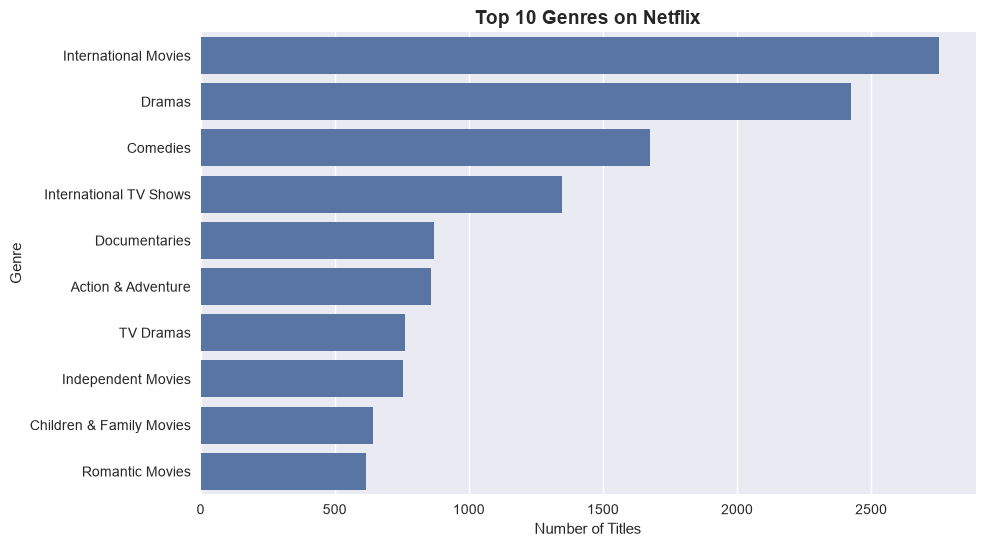

In [ ]:
plt.figure(figsize = (10,6))

sns.barplot(x = genre_counts.head(10).values, y = genre_counts.head(10).index)

plt.title("Top 10 Genres on Netflix",fontsize = 14, fontweight = 'bold')
plt.xlabel("Number of Titles")
plt.ylabel("Genre")


plt.savefig("./images/genre_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Observation
International Movies and Dramas are among the most common genres available on Netflix. This suggests that the platform offers a diverse collection of globally produced content while maintaining a strong focus on dramatic storytelling.

### Insights
US-Centric Catalog: The massive lead of the U.S. confirms that, historically, Netflix's content library has been heavily weighted toward North American media production.

The "Unknown" Data Gap: Having "Unknown" as a top-three category suggests that a significant portion of the dataset lacks geographical metadata. Before performing any deep-dive geographical analysis, you might want to investigate these "Unknown" rows to see if they can be categorized or if they should be excluded.

Global Expansion: The inclusion of countries like India, South Korea, Japan, and Spain demonstrates Netflix’s aggressive expansion into international markets, moving beyond just U.S.-based content to appeal to diverse global audiences.

Geographical Imbalance: The sharp drop-off in production volume after the top two countries (U.S. and India) shows that content production is highly concentrated in a few major hubs rather than being evenly distributed across the globe.

In [94]:
# Who are the Top 10 Directors on Netflix?
director_counts = (df_clean[df_clean["director"] != "Unknown"]["director"].str.split(", ").explode().value_counts())

director_counts.head(10)

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64

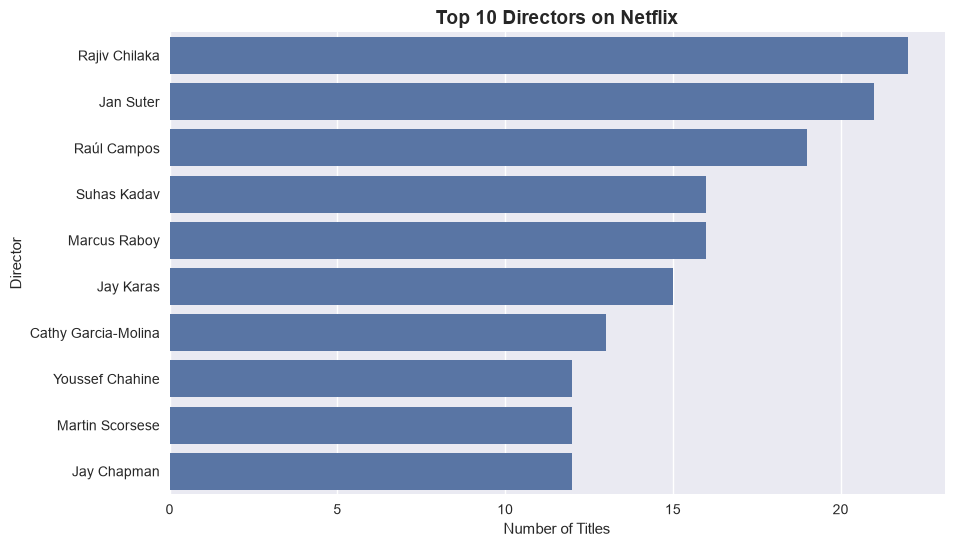

In [ ]:
plt.figure(figsize = (10,6))

sns.barplot(x = director_counts.head(10).values, y = director_counts.head(10).index)

plt.title("Top 10 Directors on Netflix",fontsize = 14, fontweight = 'bold')
plt.xlabel("Number of Titles")
plt.ylabel("Director")


plt.savefig("./images/director_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Observation
A small number of directors contribute multiple titles to the Netflix catalog, while most directors appear only a few times. This indicates that Netflix collaborates with a wide range of filmmakers rather than relying heavily on a limited group.

### Insights
Quantity vs. Popularity: It is important to note that "frequent" does not necessarily mean "famous." While Martin Scorsese is a globally renowned filmmaker, directors like Rajiv Chilaka (known for the Chhota Bheem series) appear at the top because they have produced a high volume of individual episodes or entries in a specific franchise.

Diverse Directorial Portfolio: The presence of names from different regional film industries (e.g., Rajiv Chilaka from India, Cathy Garcia-Molina from the Philippines, Youssef Chahine from Egypt) highlights Netflix’s commitment to hosting a global library of content.

Content Nature: The relatively low counts for the "Top 10" (all between 12 and 22 titles) indicate that most Netflix content is either one-off movies or projects directed by a wide variety of different people, rather than a few directors churning out hundreds of films each.

In [96]:
# Which Actors Appear Most Frequently?
actor_counts = (df_clean[df_clean["cast"] != "Unknown"]["cast"].str.split(", ").explode().value_counts())

actor_counts.head(10)

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64

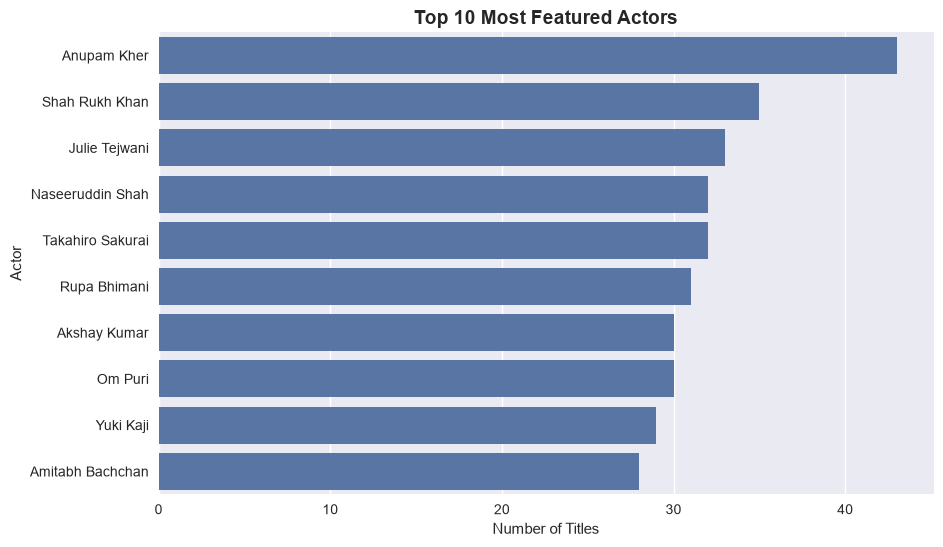

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=actor_counts.head(10).values,
    y=actor_counts.head(10).index
)

plt.title("Top 10 Most Featured Actors",fontsize = 14, fontweight = 'bold')
plt.xlabel("Number of Titles")
plt.ylabel("Actor")


plt.savefig("./images/actor_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Observation
The most frequently appearing actors are featured across multiple Netflix titles, reflecting their active involvement in film and television productions. However, the overall distribution suggests a diverse cast across the platform's content library.

### Insights
Volume vs. Star Power: The high frequency of actors like Julie Tejwani and Rupa Bhimani—who are well-known voice actors for children's programming (such as Chhota Bheem)—illustrates that "most featured" actors often include those who participate in high-volume, episodic content rather than just live-action movie stars.

Global Content Strategy: The mix of Indian cinema giants and Japanese voice actors highlights Netflix's strategic emphasis on localized content hubs, particularly in regions where Netflix has invested heavily in licensed and original productions.

Representation: The absence of prominent Hollywood actors in the top 10 is an interesting observation, suggesting that the dataset might be skewed toward international markets or that these specific actors appear in a higher density of titles (like anime series or long-running shows) compared to their Western counterparts.

In [98]:
# What is the Distribution of Movie Durations?
# We'll only analyze movies, since TV shows use seasons instead of minutes.

movies = df_clean[df_clean["type"] == "Movie"]
movies["duration_value"].describe()

count    6126.000000
mean       99.584884
std        28.283225
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_value, dtype: float64

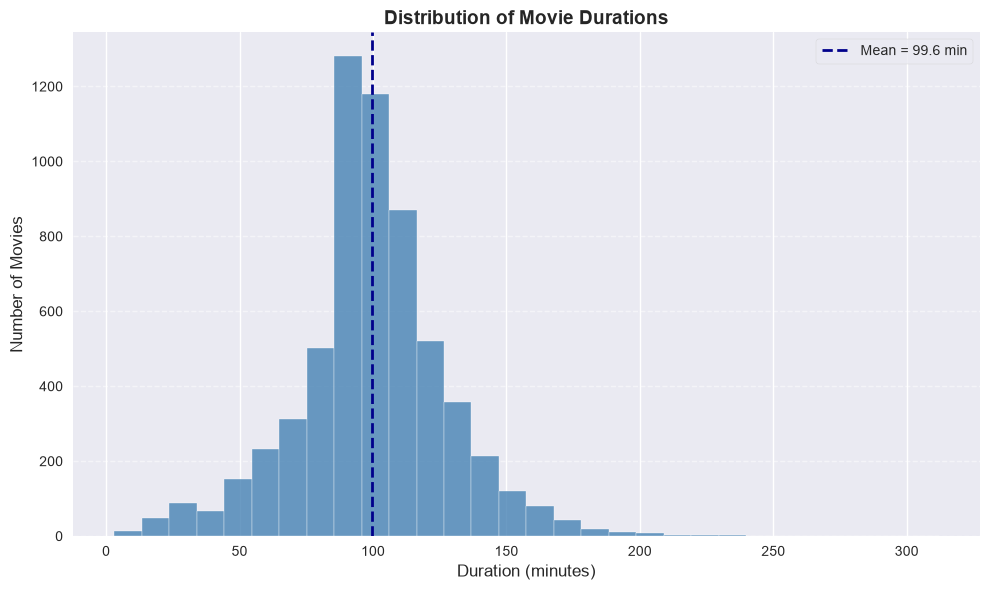

In [ ]:
plt.figure(figsize=(10, 6))

# Added color and edgecolor for better bar definition
plt.hist(
    movies["duration_value"], 
    bins=30, 
    color='steelblue', 
    edgecolor='white', 
    alpha=0.8
)

# Style the mean line
plt.axvline(
    movies["duration_value"].mean(),
    color='darkblue', 
    linestyle="--",
    linewidth=2,
    label=f"Mean = {movies['duration_value'].mean():.1f} min"
)

plt.title("Distribution of Movie Durations",fontsize = 14, fontweight = 'bold')
plt.xlabel("Duration (minutes)", fontsize=12)
plt.ylabel("Number of Movies", fontsize=12)

# Added a light grid behind the bars for readability
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(frameon=True)
plt.tight_layout()
plt.savefig("./images/content_duration_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Observation
Most Netflix movies have a runtime between 80 and 120 minutes, which aligns with the standard length of feature films. Only a small number of movies have unusually short or long durations.

### Insights
Standardized Production: The narrow, concentrated peak suggests that most films on the platform adhere to a traditional, standardized runtime, likely designed to fit conventional cinema or broadcast slots.

The "Mean" Anchor: The mean duration of 99.6 minutes acts as a strong anchor for the dataset, illustrating that Netflix’s movie catalog is heavily built around the ~100-minute feature-length format.

Right Skewness: The distribution is slightly skewed to the right, indicating that while it is rare to find extremely long movies (e.g., 3+ hours), it is much more common to find shorter, "quick-watch" films (e.g., < 60 minutes) than it is to find epic-length productions.


In [100]:
# Compare Movie vs TV Show Counts by Year
content_by_year = (
    df_clean.groupby(["year_added", "type"])
    .size()
    .unstack(fill_value=0)
)

content_by_year.head()

type,Movie,TV Show
year_added,,
2008,1,1
2009,2,0
2010,1,0
2011,13,0
2012,3,0


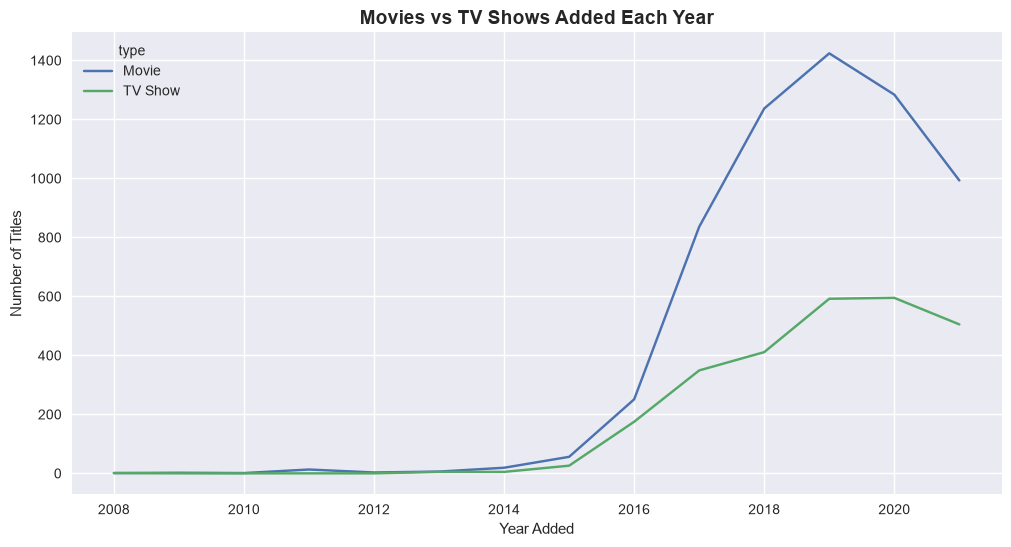

In [ ]:
content_by_year.plot(figsize=(12,6))

plt.title("Movies vs TV Shows Added Each Year",fontsize = 14, fontweight = 'bold')
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.savefig("./images/movies_vs_tv_shows.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Observation
Most TV Shows on Netflix consist of a single season, while the number of shows decreases as the number of seasons increases. This suggests that Netflix's catalog contains many limited series and recently released shows.

### Insights
Dominance of Movies: Movies clearly constitute the primary driver of the platform's content library growth, maintaining a substantial lead over TV shows in annual additions.

Shared Growth Trajectory: Despite the volume difference, both movies and TV shows followed a nearly identical timeline for their "inflection point," both beginning their aggressive climb around 2016.

Platform Maturity: The early years (2008–2015) were characterized by slow, marginal additions for both types, marking the platform's initial phase before it scaled into a major content producer and distributor.


In [102]:
# How Many Seasons Do TV Shows Typically Have?
tv_shows = df_clean[df_clean["type"] == "TV Show"]

tv_shows["duration_value"].describe()

count    2664.000000
mean        1.751877
std         1.550622
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_value, dtype: float64

In [103]:
tv_shows["duration_value"].value_counts().sort_index()


duration_value
1     1791
2      421
3      198
4       94
5       64
6       33
7       23
8       17
9        9
10       6
11       1
12       2
13       2
15       2
17       1
Name: count, dtype: int64

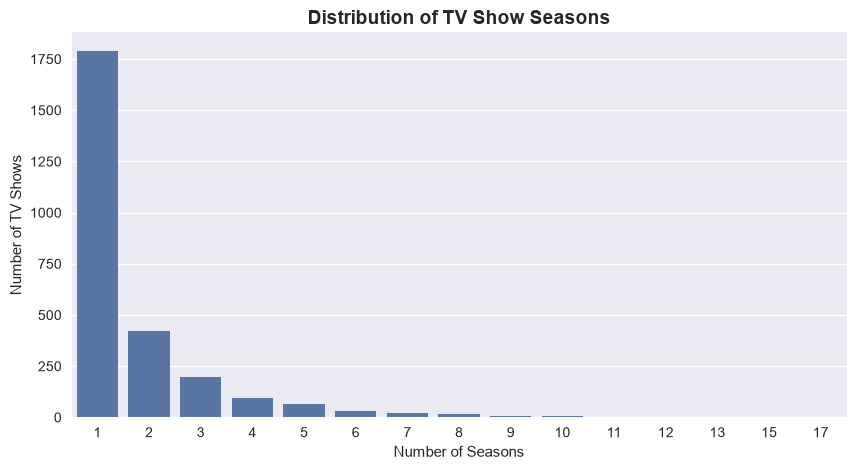

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=tv_shows,
    x="duration_value"
)

plt.title("Distribution of TV Show Seasons",fontsize = 14, fontweight = 'bold')
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")


plt.savefig("./images/distribution_tv_shows_seasons.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Observation
Netflix adds content throughout the year, although some months experience noticeably higher numbers of additions than others. This indicates that content releases are distributed across the calendar rather than concentrated in a single season.

### Insights
"Limited Series" Dominance: The extreme skew toward single-season content suggests that the platform's library is heavily populated by limited series, miniseries, or shows that were canceled after their first attempt.

High Attrition Rate: The steep decay curve is a classic "power law" distribution. It indicates that very few shows successfully capture the sustained audience or budget required to reach mid-to-high double-digit season counts.

Platform Strategy: This distribution reflects a content strategy that prioritizes a high volume of new, experimental, or short-form content rather than relying on a small number of decade-spanning "prestige" dramas.


In [105]:
# Which Month Does Netflix Add the Most Content?
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

month_counts = (
    df_clean["month_added"]
    .value_counts()
    .reindex(month_order)
)

month_counts

month_added
January      737
February     562
March        741
April        763
May          632
June         728
July         827
August       754
September    769
October      760
November     705
December     812
Name: count, dtype: int64

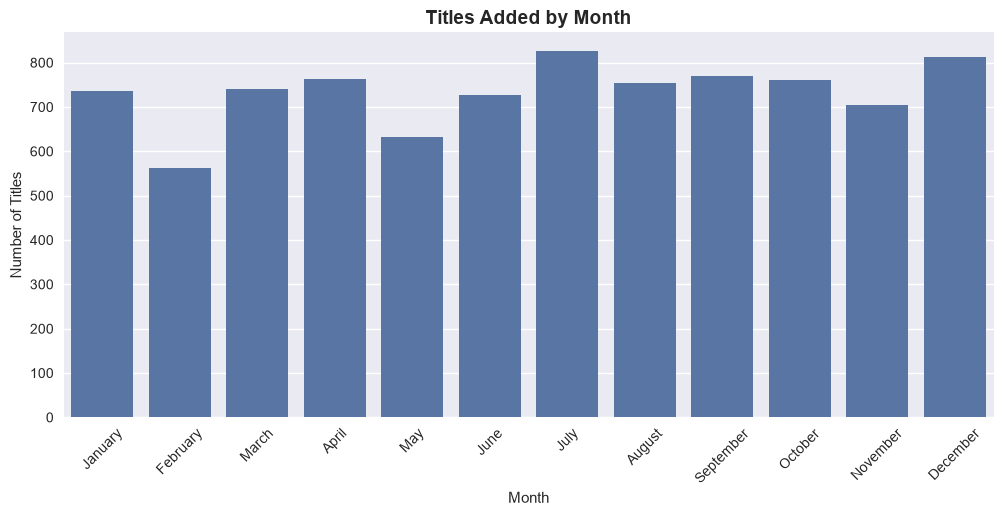

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=month_counts.index,
    y=month_counts.values
)

plt.title("Titles Added by Month", fontsize = 14, fontweight = 'bold')
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)


plt.savefig("./images/titles_added_by_month.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Observation
Most of the top content-producing countries contribute more movies than TV Shows to Netflix's catalog. While some countries have a balanced mix of content types, movies remain the dominant format across the majority of regions.

### Insights
Seasonal Volatility: The variation in monthly additions suggests that the platform does not release content at a perfectly uniform rate. This could reflect strategic programming decisions, such as "dumping" content during peak vacation or holiday periods (like July and December) to maximize viewership.

The "February Slump": The notable dip in February suggests a lower priority for content releases during this period, potentially to avoid competition or due to internal production scheduling cycles.

In [107]:
# Which Countries Produce More Movies vs TV Shows?
# We'll again use only the first listed country to keep the analysis simple.

country_type = df_clean.copy()
country_type["primary_country"] = (country_type["country"].str.split(", ").str[0])

# Remove unknown countries
country_type = country_type[country_type["primary_country"] != "Unknown"]

In [108]:
top_countries = (country_type["primary_country"].value_counts().head(10).index)

filtered = country_type[country_type["primary_country"].isin(top_countries)]

country_vs_type = pd.crosstab(filtered["primary_country"],filtered["type"])

country_vs_type

type,Movie,TV Show
primary_country,,
Australia,61,54
Canada,187,84
France,148,64
India,927,81
Japan,85,172
Mexico,86,48
South Korea,47,164
Spain,129,52
United Kingdom,380,245


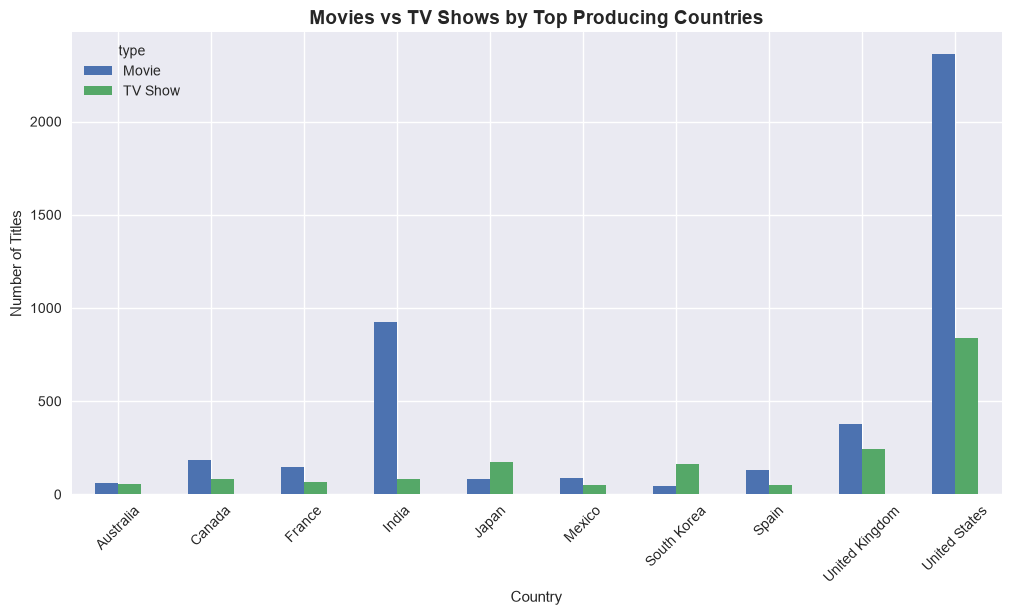

In [ ]:
country_vs_type.plot(kind="bar",figsize=(12,6))

plt.title("Movies vs TV Shows by Top Producing Countries", fontsize = 14, fontweight = 'bold')
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)


plt.savefig("./images/movies_vs_tv_shows_by_country.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Observation

Most of the top content-producing countries contribute more movies than TV Shows to Netflix's catalog. While some countries have a balanced mix of content types, movies remain the dominant format across the majority of regions.

### Insights
Cultural Content Specialization: The data reveals a clear regional specialization: North American and European markets lean heavily into film production, while the East Asian markets (Japan/South Korea) focus their platform presence on episodic series.

The "Bollywood" Influence: India’s extreme skew toward movies highlights the historical and industry-wide focus of its film culture, which is heavily dominated by the cinematic tradition of feature-length releases.

Platform Strategy by Region: This chart demonstrates that Netflix adapts its acquisition and production strategy based on the local industry strengths of each country. It does not try to force a uniform ratio; instead, it leans into the established production habits of the local market (movies in India, shows in Japan).


## 4. Project Summary

### Key Insights
- Exponential Scaling: The platform underwent a dramatic "inflection point" around 2016, transitioning from slow, steady growth to an aggressive, large-scale expansion of both movie and TV show titles.

- Movie-Dominant Library: Across almost all major producing countries, feature films consistently represent a larger share of the total library compared to TV series.

- Regional Specialization: Netflix's global strategy adapts to local industry strengths; for example, the catalog is heavily movie-focused in India, while Japanese and South Korean content production is centered on episodic series.

- Short-Form TV Dominance: The distribution of TV shows follows a strict power-law structure, with the vast majority of titles consisting of only a single season, suggesting a library filled with miniseries or limited-run projects.

- Standardized Movie Length: The majority of films adhere to a traditional, standardized runtime, with the distribution sharply peaking around the 100-minute mark.

- Data Censoring: A sharp decline in additions during 2020–2021 is observable in the data, which serves as a critical indicator of incomplete reporting rather than a decrease in actual production.

- Content Concentration: While top directors and actors appear frequently, their total counts are small relative to the library size, reflecting a highly diversified catalog rather than one dominated by a few individuals.

- Variable Seasonal Cadence: Content additions are not uniformly distributed; the platform utilizes a distinct release cadence with peak activity in July and December and a notable lull in February.

## Conclusion

This project demonstrated the complete EDA workflow, including data cleaning, feature engineering, visualization, and insight generation. The analysis showed that Netflix's catalog is dominated by movies, mature-rated content, and productions from the United States and India, while also highlighting rapid catalog growth during the late 2010s.